In [11]:
# Cell 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report, RocCurveDisplay
)


In [12]:
# Cell 2: Load dataset
df = pd.read_csv("../Data/final_classification_ready.csv")
print("Shape:", df.shape)
df.head()


Shape: (45155, 16)


,MONTH,DAY_OF_MONTH,DAY_OF_WEEK,CRS_DEP_TIME,CRS_ARR_TIME,CRS_ELAPSED_TIME,DISTANCE,HourlyDewPointTemperature,HourlyDryBulbTemperature,HourlyRelativeHumidity,HourlyVisibility,HourlyWindSpeed,DEP_DEL15,OP_UNIQUE_CARRIER_ENC,ORIGIN_ENC,DEST_ENC
0,4,1,2,6.53,9.33,168.0,1020.0,33.0,36.0,89.0,5.0,10.0,0.0,0,1,62
1,4,1,2,15.45,18.12,160.0,1020.0,33.0,45.0,63.0,10.0,10.0,1.0,0,1,62
2,4,1,2,7.33,15.32,299.0,2279.0,37.0,43.0,80.0,10.0,6.0,0.0,0,4,14
3,4,1,2,13.83,21.83,300.0,2279.0,41.0,49.0,74.0,10.0,6.0,0.0,0,4,14
4,4,1,2,22.00,6.00,300.0,2279.0,41.0,45.0,86.0,10.0,7.0,0.0,0,4,14


In [13]:
# Cell 3: Split features and target
X = df.drop(columns=["DEP_DEL15"])
y = df["DEP_DEL15"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape, "| Test:", X_test.shape)


Train: (36124, 15) | Test: (9031, 15)


In [14]:
# Cell 4: Scale & balance with SMOTE
from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

sm = SMOTE(random_state=42)
X_train_bal, y_train_bal = sm.fit_resample(X_train_scaled, y_train)

print("Trước SMOTE:", np.bincount(y_train))
print("Sau SMOTE:", np.bincount(y_train_bal))


Trước SMOTE: [31882  4242]
Sau SMOTE: [31882 31882]


C:\Users\PC\AppData\Local\Temp\ipykernel_12328\426419774.py:12: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  print("Trước SMOTE:", np.bincount(y_train))
C:\Users\PC\AppData\Local\Temp\ipykernel_12328\426419774.py:13: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  print("Sau SMOTE:", np.bincount(y_train_bal))


In [15]:
# Cell 5: GridSearchCV
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',
    cv=3,
    n_jobs=-1,
    verbose=2
)

grid_search.fit(X_train_bal, y_train_bal)

print("✅ Best Parameters:", grid_search.best_params_)
print("✅ Best F1-score (CV):", grid_search.best_score_)


Fitting 3 folds for each of 108 candidates, totalling 324 fits
✅ Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 300}
✅ Best F1-score (CV): 0.9171213827501923


In [16]:
# Cell 6: Evaluate best model
best_rf = grid_search.best_estimator_

y_pred = best_rf.predict(X_test_scaled)
y_prob = best_rf.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
pre = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc = roc_auc_score(y_test, y_prob)

print("📊 Random Forest (GridSearchCV + SMOTE) Performance:")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {pre:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")
print(f"ROC-AUC  : {roc:.4f}")


📊 Random Forest (GridSearchCV + SMOTE) Performance:
Accuracy : 0.8590
Precision: 0.2874
Recall   : 0.1358
F1-score : 0.1845
ROC-AUC  : 0.6919


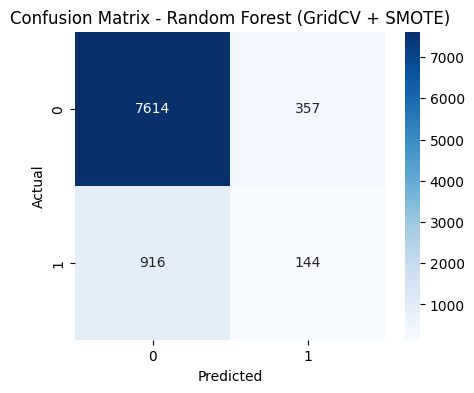

In [17]:
# Cell 7: Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest (GridCV + SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


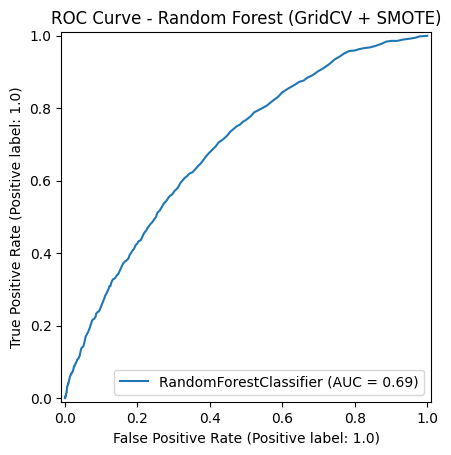

In [18]:
# Cell 8: ROC Curve
RocCurveDisplay.from_estimator(best_rf, X_test_scaled, y_test)
plt.title("ROC Curve - Random Forest (GridCV + SMOTE)")
plt.show()


In [19]:
# Cell 9: Classification report
print("Classification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

         0.0       0.89      0.96      0.92      7971
         1.0       0.29      0.14      0.18      1060

    accuracy                           0.86      9031
   macro avg       0.59      0.55      0.55      9031
weighted avg       0.82      0.86      0.84      9031



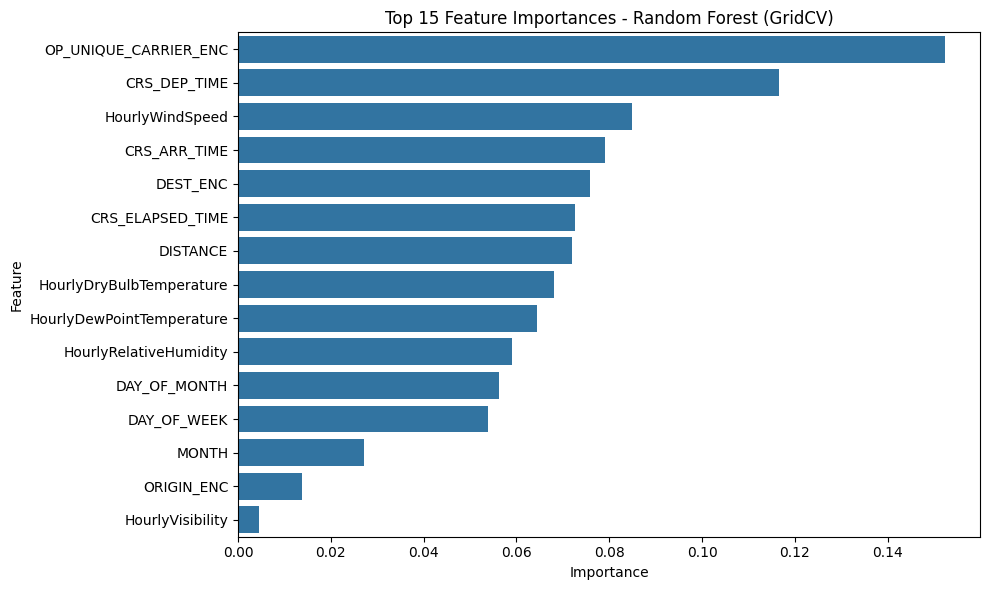

In [20]:
# Cell 10: Feature importance
feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x="Importance", y="Feature", data=feat_imp.head(15))
plt.title("Top 15 Feature Importances - Random Forest (GridCV)")
plt.tight_layout()
plt.show()
